In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

sns.set_theme(style="whitegrid", context="notebook")

In [47]:
df=pd.read_csv('/content/Bank_Personal_Loan_Modelling.csv')

In [48]:
df.shape

(5000, 14)

In [49]:
df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1/60,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1/50,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1/00,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2/70,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1/00,2,0,0,0,0,0,1


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  5000 non-null   int64 
 1   Age                 5000 non-null   int64 
 2   Experience          5000 non-null   int64 
 3   Income              5000 non-null   int64 
 4   ZIP Code            5000 non-null   int64 
 5   Family              5000 non-null   int64 
 6   CCAvg               5000 non-null   object
 7   Education           5000 non-null   int64 
 8   Mortgage            5000 non-null   int64 
 9   Personal Loan       5000 non-null   int64 
 10  Securities Account  5000 non-null   int64 
 11  CD Account          5000 non-null   int64 
 12  Online              5000 non-null   int64 
 13  CreditCard          5000 non-null   int64 
dtypes: int64(13), object(1)
memory usage: 547.0+ KB


In [51]:
df.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIP Code,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal Loan,0


In [52]:
df['CCAvg'] = df['CCAvg'].str.replace('/', '.', regex=False).astype(float)

In [53]:
df.drop(columns=['ID'],inplace=True)

In [54]:
df.sample(10)

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
733,49,24,80,92009,1,1.200,1,0,0,0,0,1,0
442,58,28,122,95136,1,3.000,3,115,1,0,0,1,0
3957,40,15,75,95449,4,1.100,2,0,0,0,0,1,0
313,34,9,41,93720,3,2.300,1,0,0,0,0,0,1
4411,23,-2,75,90291,2,1.800,2,0,0,0,0,1,1
48,56,26,81,95747,2,4.500,3,0,0,0,0,0,1
3952,61,36,124,94611,2,3.900,1,0,0,1,0,0,1
635,60,35,35,90509,3,0.200,1,169,0,0,0,1,0
3115,31,5,111,94305,2,0.200,1,0,0,0,0,0,0
806,53,27,44,94542,4,1.500,3,0,0,0,0,0,0


In [55]:
df.duplicated().sum()

np.int64(0)

In [56]:
#there is a noisy data in experience colummn
df[df['Experience']<0]['Experience'].value_counts()

,count
Experience,
-1,33
-2,15
-3,4


In [57]:
df['Experience']=df['Experience'].apply(abs)

In [58]:
df["ZIP Code"].nunique()

467

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Income              5000 non-null   int64  
 3   ZIP Code            5000 non-null   int64  
 4   Family              5000 non-null   int64  
 5   CCAvg               5000 non-null   float64
 6   Education           5000 non-null   int64  
 7   Mortgage            5000 non-null   int64  
 8   Personal Loan       5000 non-null   int64  
 9   Securities Account  5000 non-null   int64  
 10  CD Account          5000 non-null   int64  
 11  Online              5000 non-null   int64  
 12  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 507.9 KB


 Define variable groups

In [60]:
TARGET = "Personal Loan"
numerical_columns = ["Age","Experience","Income","CCAvg","Mortgage",]
categorical_columns = ["Family","Education","Securities Account","CD Account","Online","CreditCard",]
location_columns = ["ZIP Code"]
binary_columns = ["Securities Account","CD Account","Online","CreditCard",]

# **Exploratory Data Analysis**

Target Column






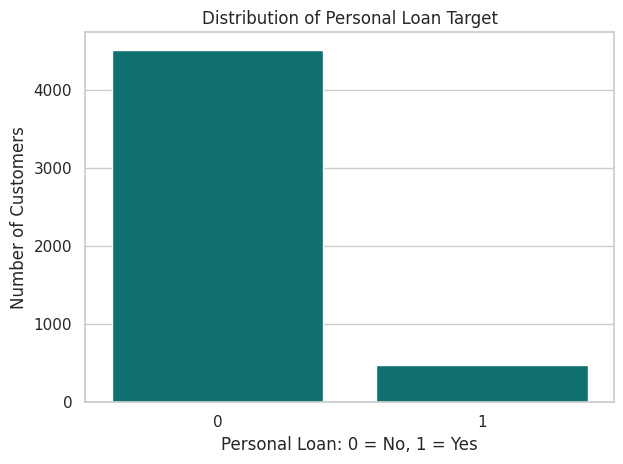

In [61]:
sns.countplot(x=TARGET,data=df,color='teal')
plt.title("Distribution of Personal Loan Target")
plt.xlabel("Personal Loan: 0 = No, 1 = Yes")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

numerical variables

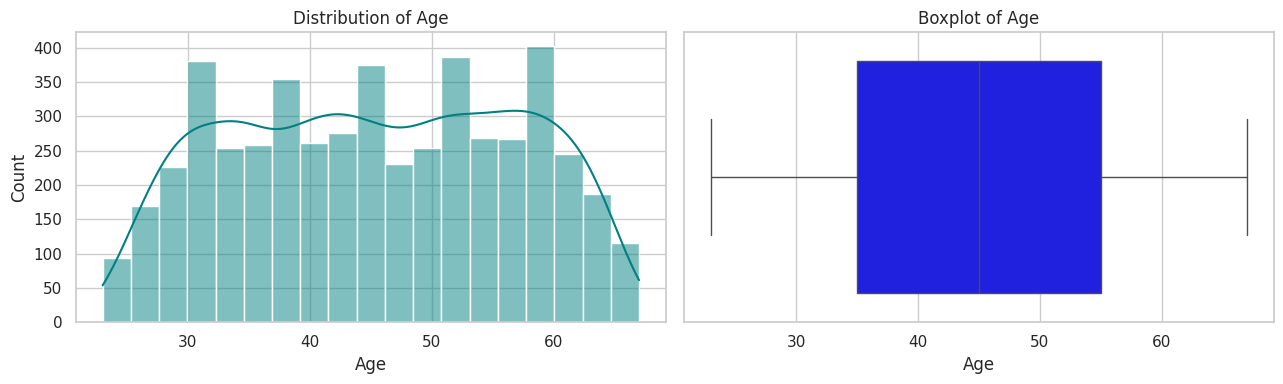

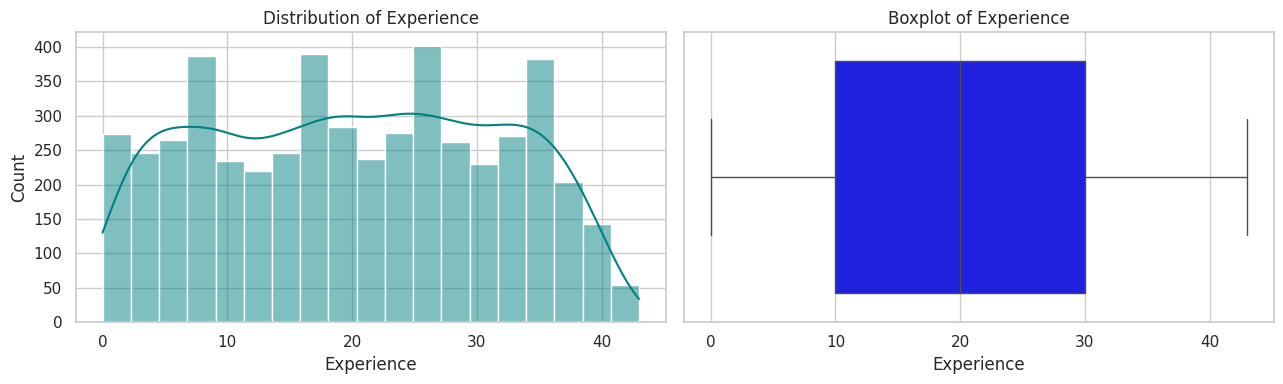

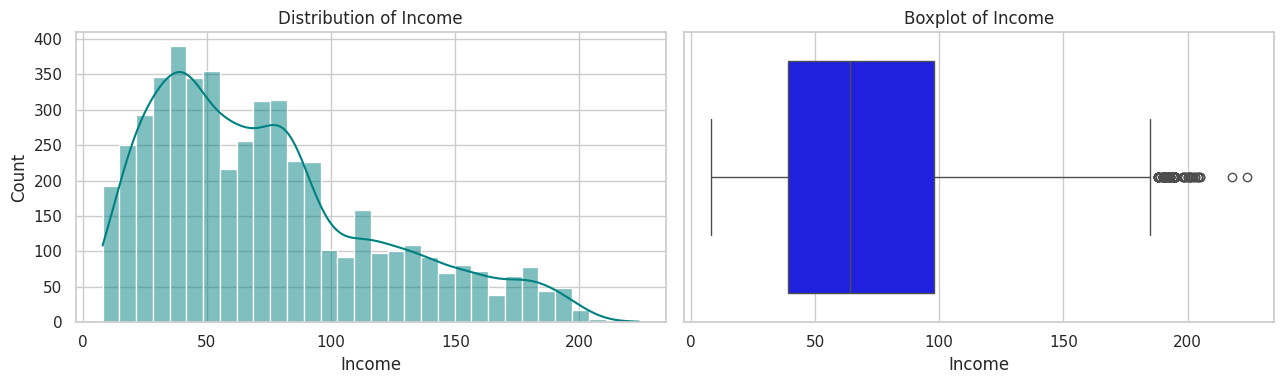

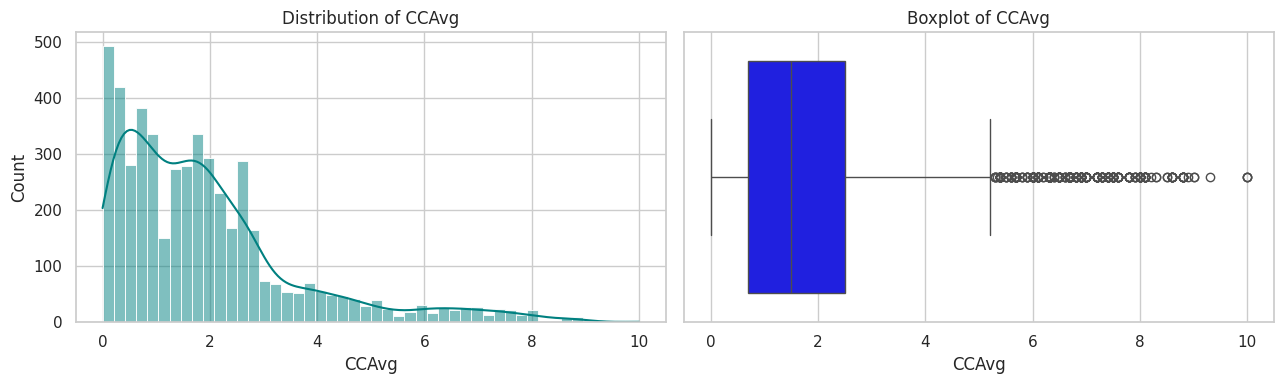

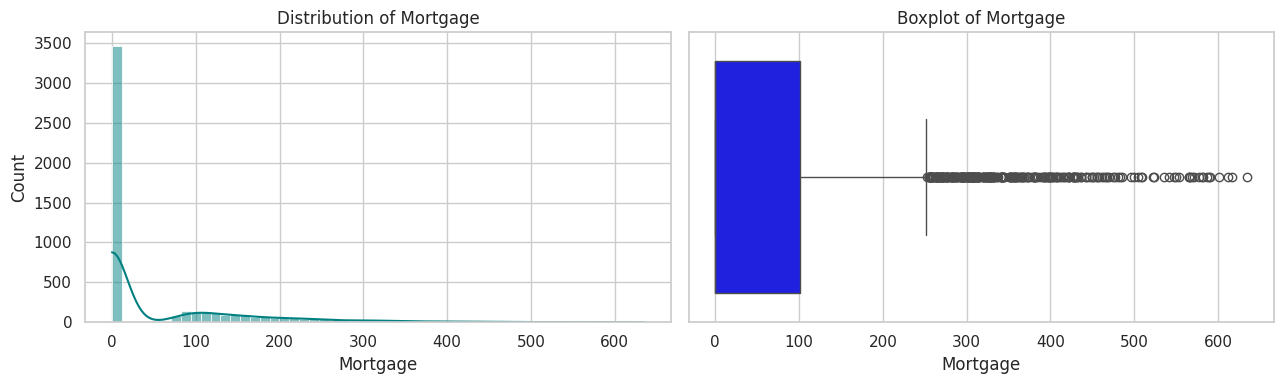

In [62]:
def plot_numerical_distributions(data, columns):
    for column in columns:
        fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(13, 4),)
        sns.histplot(data=data, x=column,kde=True,ax=axes[0],color='teal')
        axes[0].set_title(f"Distribution of {column}")

        sns.boxplot(data=data,x=column,ax=axes[1],color='blue')
        axes[1].set_title(f"Boxplot of {column}")

        plt.tight_layout()
        plt.show()


plot_numerical_distributions( df, numerical_columns)

In [67]:
numerical_summary = df[numerical_columns].describe().T
numerical_summary["Skewness"] = (df[numerical_columns].skew())
numerical_summary["Kurtosis"] = (df[numerical_columns].kurtosis())
numerical_summary["Unique Values"] = (df[numerical_columns].nunique())

numerical_summary

,count,mean,std,min,25%,50%,75%,max,Skewness,Kurtosis,Unique Values
Age,"5,000.000",45.338,11.463,23.000,35.000,45.000,55.000,67.000,-0.029,-1.153,45
Experience,"5,000.000",20.135,11.415,0.000,10.000,20.000,30.000,43.000,-0.010,-1.144,44
Income,"5,000.000",73.774,46.034,8.000,39.000,64.000,98.000,224.000,0.841,-0.044,162
CCAvg,"5,000.000",1.938,1.748,0.000,0.700,1.500,2.500,10.000,1.598,2.647,108
Mortgage,"5,000.000",56.499,101.714,0.000,0.000,0.000,101.000,635.000,2.104,4.757,347


 IQR outlier report


In [68]:
def create_iqr_outlier_report(data, columns):
    report = []
    for column in columns:
        q1 = data[column].quantile(0.25)
        q3 = data[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outlier_mask = ((data[column] < lower_bound)| (data[column] > upper_bound))

        report.append(
            {
                "Feature": column,
                "Q1": q1,
                "Q3": q3,
                "IQR": iqr,
                "Lower Bound": lower_bound,
                "Upper Bound": upper_bound,
                "Outlier Count": int(outlier_mask.sum()),
                "Outlier Percentage": round( outlier_mask.mean() * 100,2)
            }
        )

    return pd.DataFrame(report)


outlier_report = create_iqr_outlier_report(df,numerical_columns)
outlier_report

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,Age,35.000,55.000,20.000,5.000,85.000,0,0.000
1,Experience,10.000,30.000,20.000,-20.000,60.000,0,0.000
2,Income,39.000,98.000,59.000,-49.500,186.500,96,1.920
3,CCAvg,0.700,2.500,1.800,-2.000,5.200,324,6.480
4,Mortgage,0.000,101.000,101.000,-151.500,252.500,291,5.820


The outlier report identifies unusual observations but does not modify them. High income, mortgage and spending values may be legitimate and important for loan prediction.

categorical variables

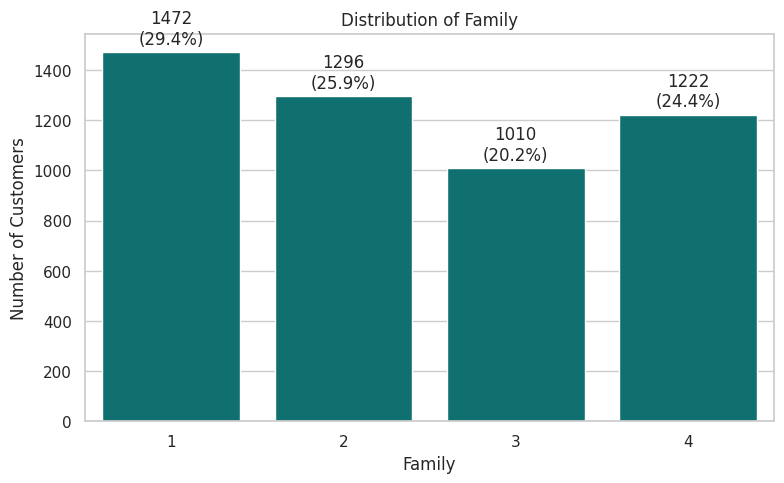

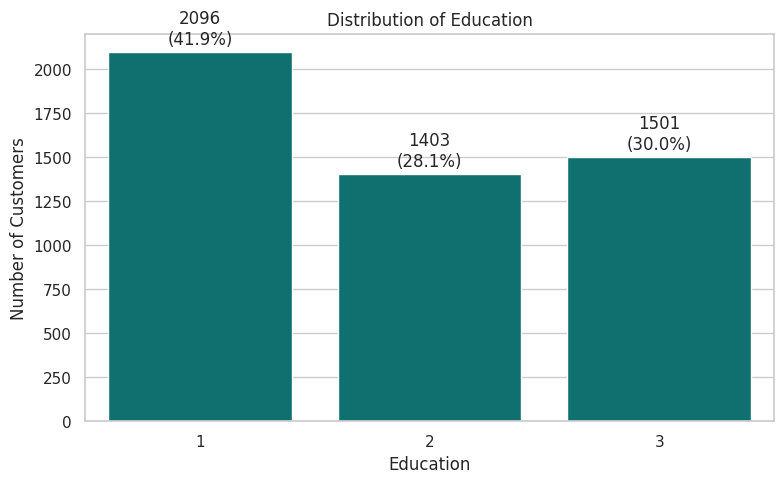

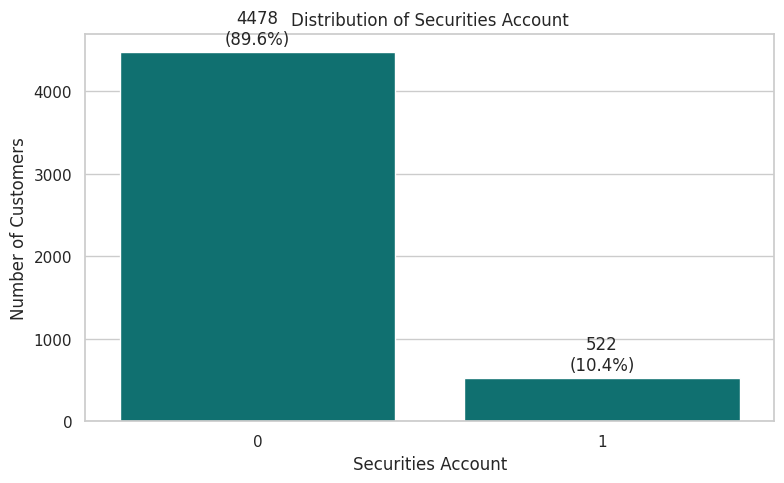

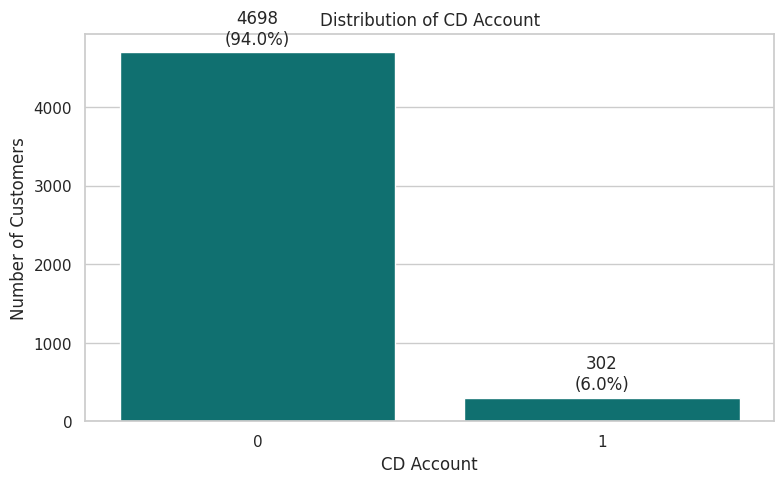

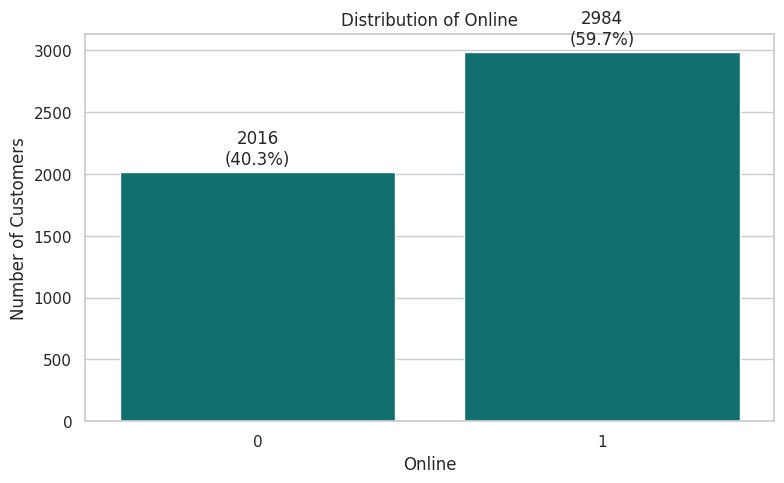

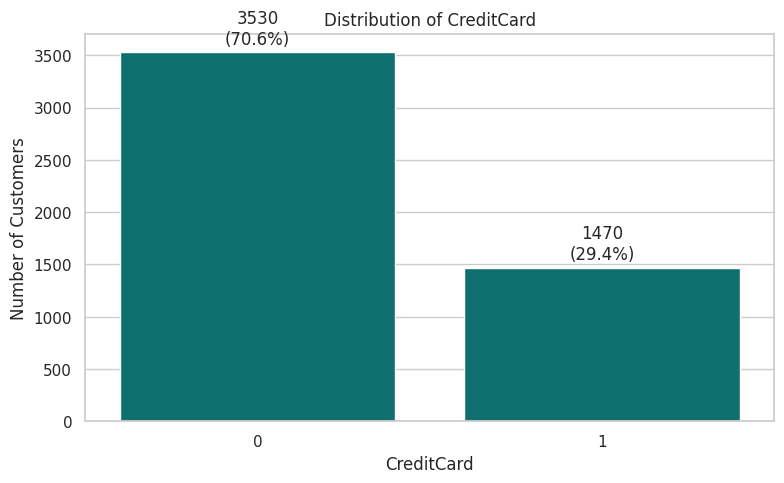

In [70]:
def plot_categorical_distributions(data, columns):
    for column in columns:
        order = sorted(data[column].dropna().unique())
        plt.figure(figsize=(8, 5))

        axis = sns.countplot(data=data,x=column,order=order,color='teal')

        total_rows = len(data)

        for container in axis.containers:
            labels = [f"{int(bar.get_height())}\n"f"({bar.get_height() / total_rows * 100:.1f}%)"for bar in container]
            axis.bar_label(container,labels=labels,padding=3,)

        plt.title(f"Distribution of {column}")
        plt.xlabel(column)
        plt.ylabel("Number of Customers")
        plt.tight_layout()
        plt.show()


plot_categorical_distributions(df, categorical_columns,)

ZIP Code analysis

In [74]:
zip_summary = (df.groupby("ZIP Code").agg( Customer_Count=(TARGET, "size"), Loan_Count=(TARGET, "sum"), Loan_Rate=(TARGET, "mean"),)
    .assign( Loan_Rate=lambda table: ( table["Loan_Rate"] * 100 ) )
    .sort_values("Customer_Count",ascending=False,)
)
print("Top ZIP codes by number of customers:")
display(zip_summary.head(20))

Top ZIP codes by number of customers:


,Customer_Count,Loan_Count,Loan_Rate
ZIP Code,,,
94720,169,19,11.243
94305,127,13,10.236
95616,116,6,5.172
90095,71,8,11.268
93106,57,4,7.018
92037,54,5,9.259
93943,54,4,7.407
91320,53,2,3.774
94025,52,4,7.692


In [79]:
zip_rate_reliable = (zip_summary[zip_summary["Customer_Count"] >= 20]
    .sort_values("Loan_Rate",ascending=False,))

print("ZIP codes with at least 20 customers, ""sorted by loan rate:")
display(zip_rate_reliable.head(15))

ZIP codes with at least 20 customers, sorted by loan rate:


,Customer_Count,Loan_Count,Loan_Rate
ZIP Code,,,
94022,25,6,24.000
91380,22,5,22.727
92182,32,7,21.875
92612,22,4,18.182
94304,45,8,17.778
95051,34,6,17.647
92093,51,9,17.647
90089,46,8,17.391
95814,30,5,16.667


# Numerical features versus target

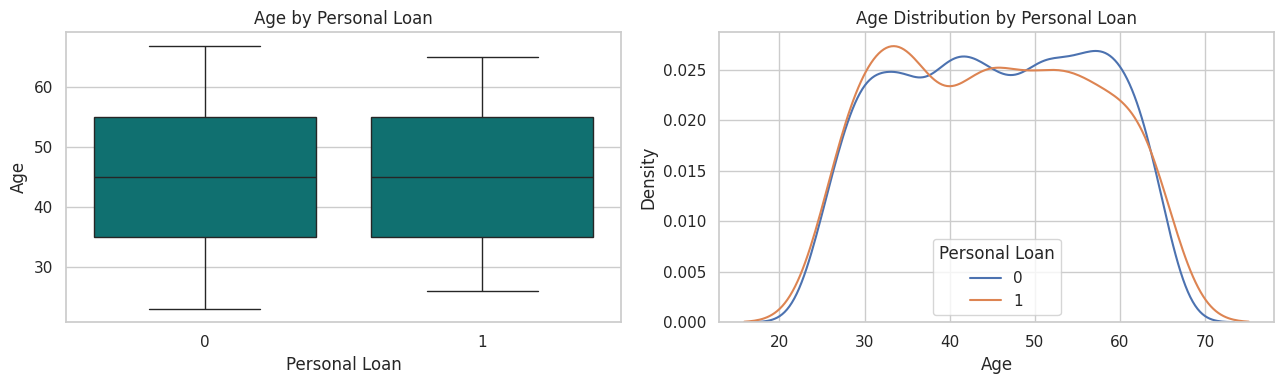

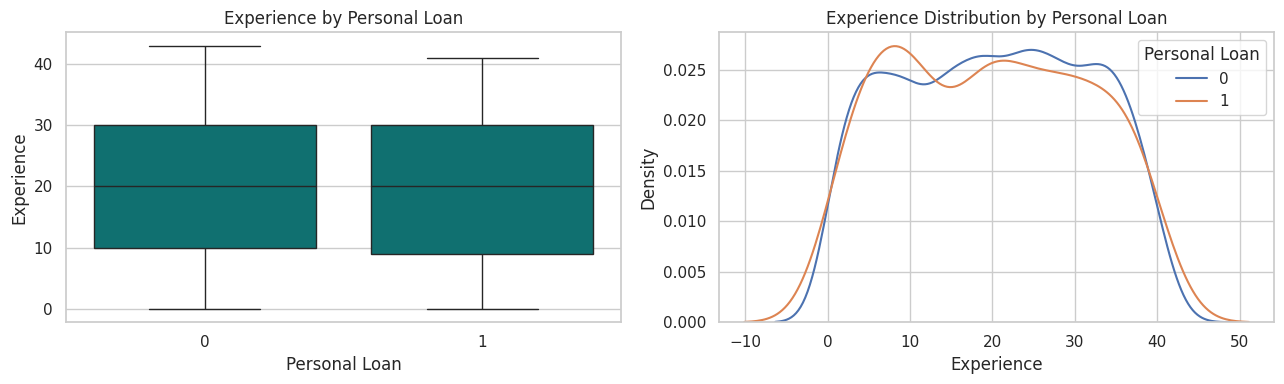

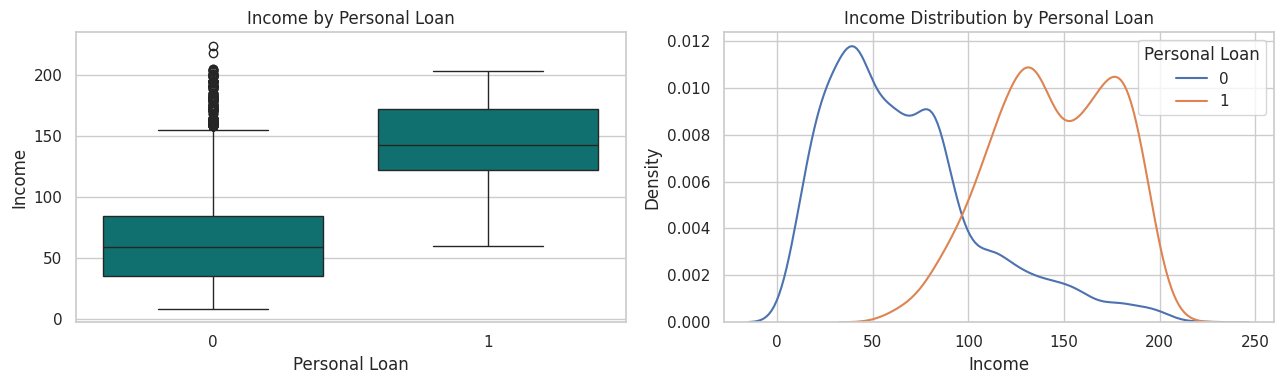

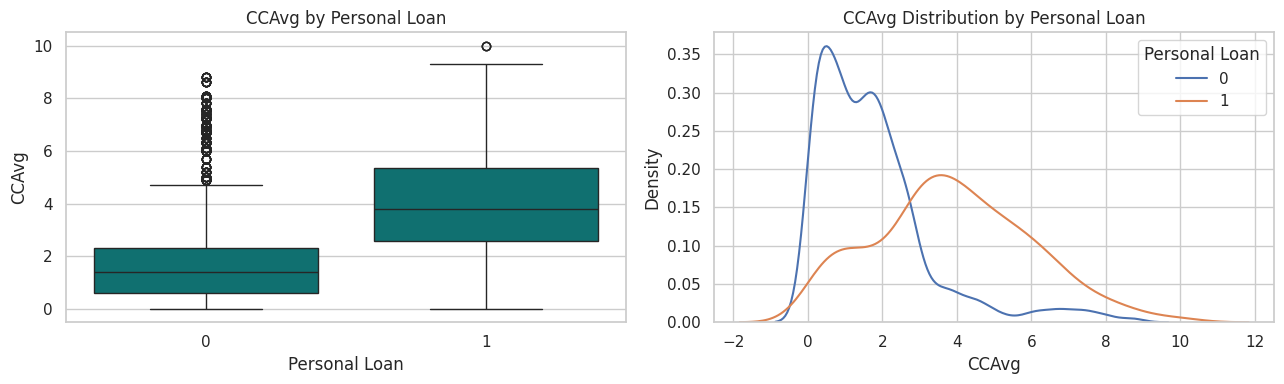

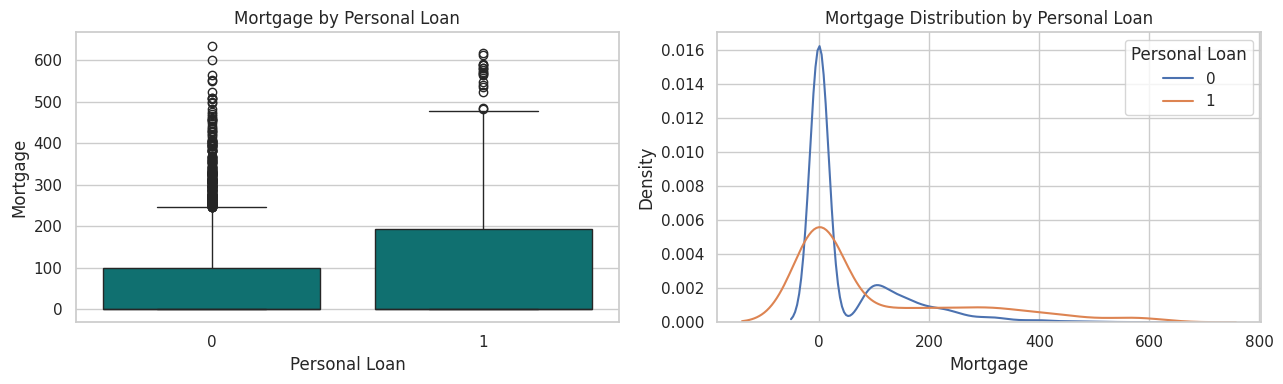

In [81]:
def plot_numerical_vs_target( data, columns,target):
    for column in columns:
        fig, axes = plt.subplots(nrows=1,ncols=2,figsize=(13, 4),)

        sns.boxplot(data=data,x=target,y=column,ax=axes[0],color='teal')
        axes[0].set_title(f"{column} by {target}")

        for target_value in sorted( data[target].unique()):
            sns.kdeplot(data=data[ data[target] == target_value],x=column, label=str(target_value), fill=False, common_norm=False, ax=axes[1],)

        axes[1].set_title(f"{column} Distribution by {target}" )
        axes[1].legend(title=target)

        plt.tight_layout()
        plt.show()


plot_numerical_vs_target(df,numerical_columns,TARGET)

In [82]:
numerical_target_summary = (df.groupby(TARGET)[numerical_columns].agg(["mean", "median"]).T)
numerical_target_summary

Personal Loan          0       1
Age        mean   45.367  45.067
           median 45.000  45.000
Experience mean   20.165  19.844
           median 20.000  20.000
Income     mean   66.237 144.746
           median 59.000 142.500
CCAvg      mean    1.729   3.905
           median  1.400   3.800
Mortgage   mean   51.789 100.846
           median  0.000   0.000

 Categorical features versus target

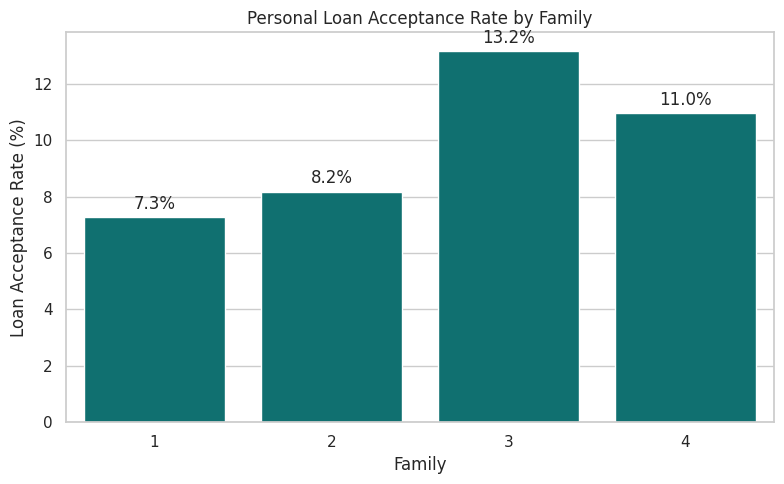

,Family,Customer Count,Loan Rate
0,1,1472,7.269
1,2,1296,8.179
2,3,1010,13.168
3,4,1222,10.966


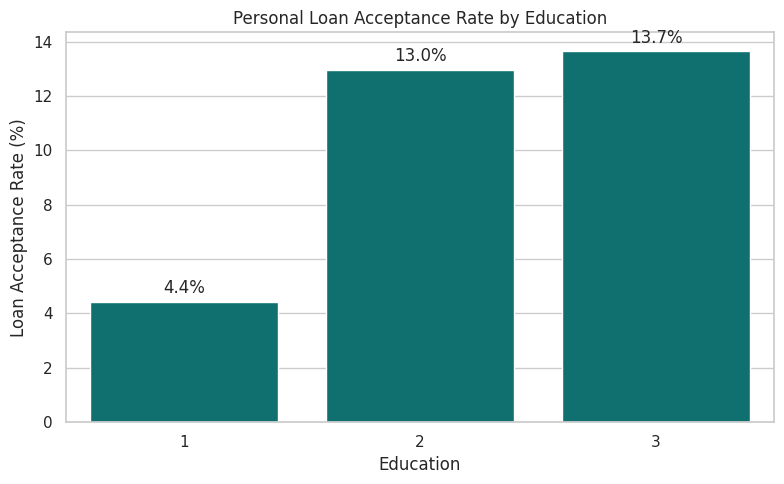

,Education,Customer Count,Loan Rate
0,1,2096,4.437
1,2,1403,12.972
2,3,1501,13.658


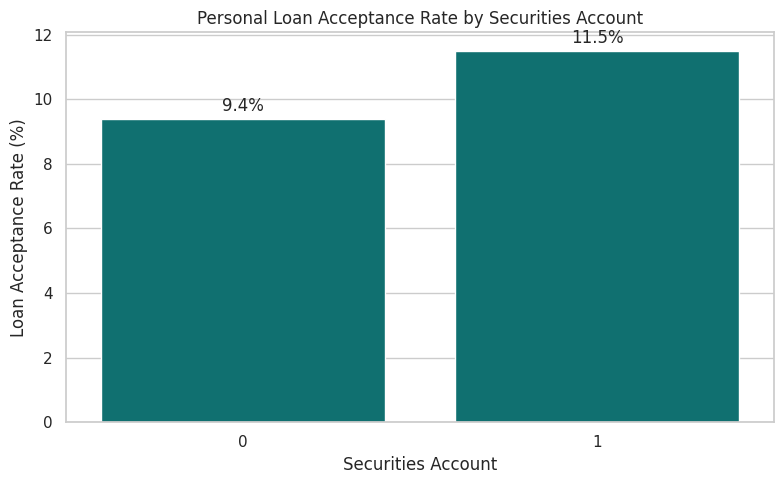

,Securities Account,Customer Count,Loan Rate
0,0,4478,9.379
1,1,522,11.494


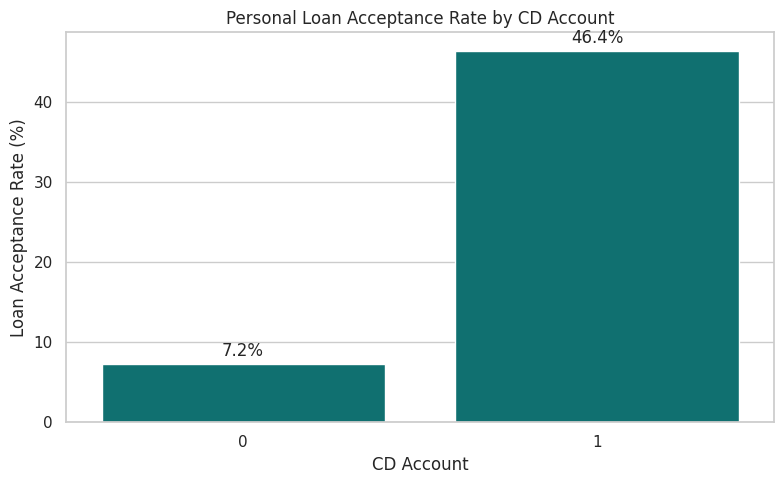

,CD Account,Customer Count,Loan Rate
0,0,4698,7.237
1,1,302,46.358


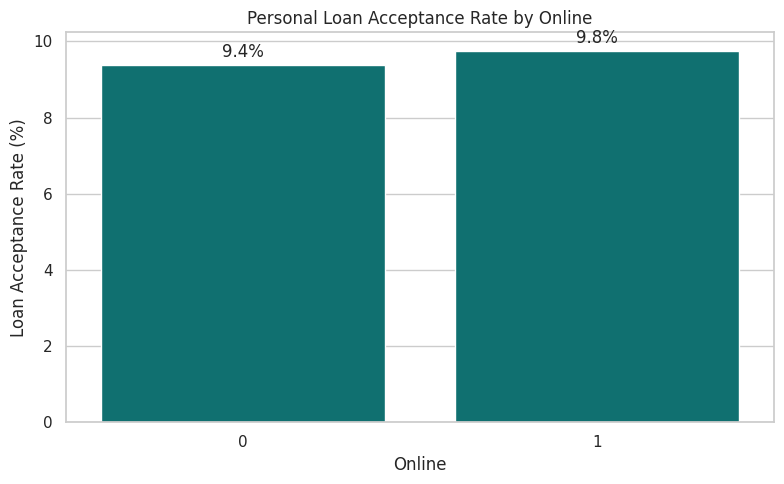

,Online,Customer Count,Loan Rate
0,0,2016,9.375
1,1,2984,9.752


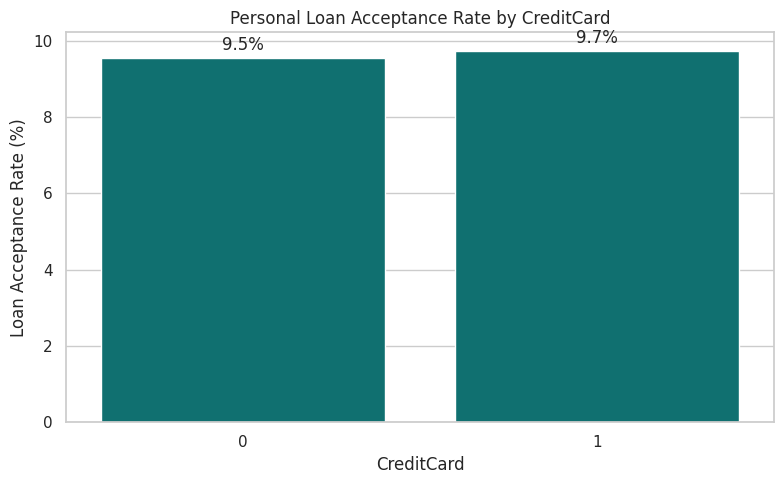

,CreditCard,Customer Count,Loan Rate
0,0,3530,9.547
1,1,1470,9.728


In [85]:
def plot_categorical_loan_rates(data,columns,target):
    for column in columns:
        loan_rate = ( data.groupby(column,observed=False,)[target].agg(["count", "mean"]).reset_index()
            .rename(
                columns={"count": "Customer Count","mean": "Loan Rate"})
        )

        loan_rate["Loan Rate"] *= 100

        plt.figure(figsize=(8, 5))

        axis = sns.barplot(data=loan_rate,x=column,y="Loan Rate",color='teal')

        for container in axis.containers:
            axis.bar_label(container,fmt="%.1f%%",padding=3,)

        plt.title(f"Personal Loan Acceptance Rate by {column}")
        plt.ylabel("Loan Acceptance Rate (%)")
        plt.tight_layout()
        plt.show()

        display(loan_rate)


plot_categorical_loan_rates( df, categorical_columns, TARGET)

Correlation analysis

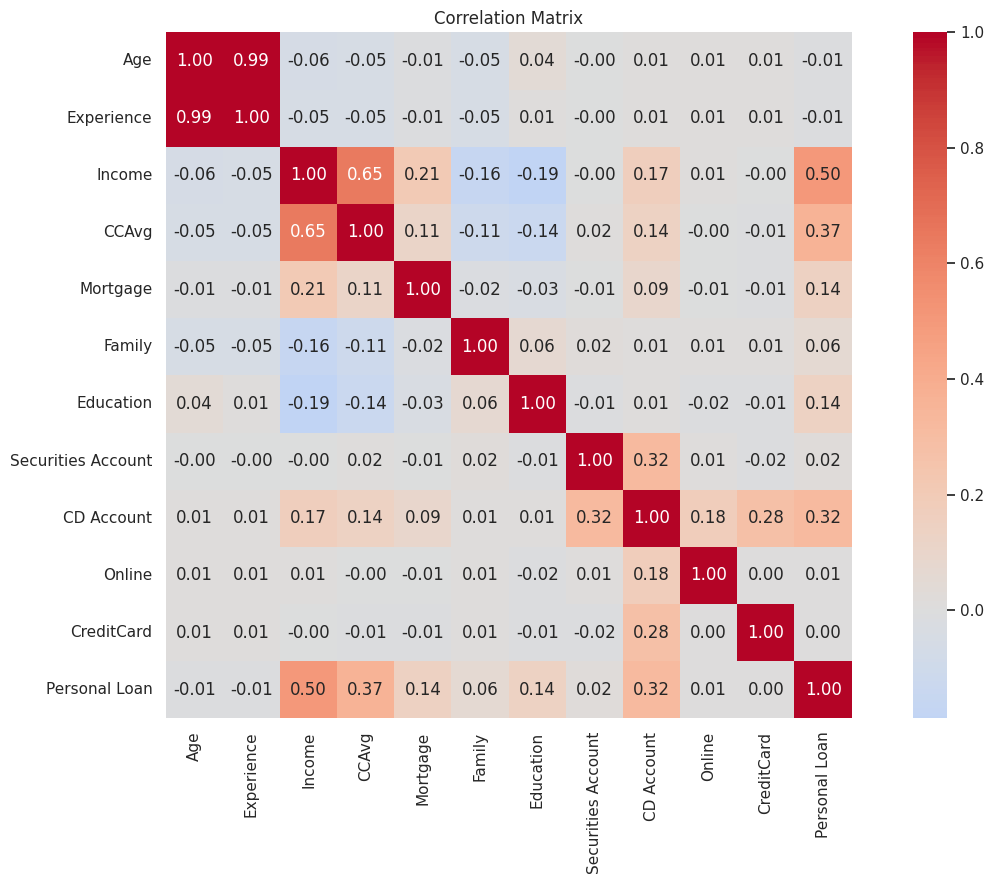

In [86]:
correlation_columns = (numerical_columns+ categorical_columns+ [TARGET])
correlation_matrix = (df[correlation_columns].corr())
plt.figure(figsize=(13, 9))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [87]:
target_correlations = (correlation_matrix[TARGET].drop(TARGET).sort_values(  key=lambda series: series.abs(), ascending=False).to_frame("Correlation with Personal Loan"))

target_correlations

,Correlation with Personal Loan
Income,0.502
CCAvg,0.367
CD Account,0.316
Mortgage,0.142
Education,0.137
Family,0.061
Securities Account,0.022
Experience,-0.008
Age,-0.008
Online,0.006


Correlation between Age and Experience: 0.994


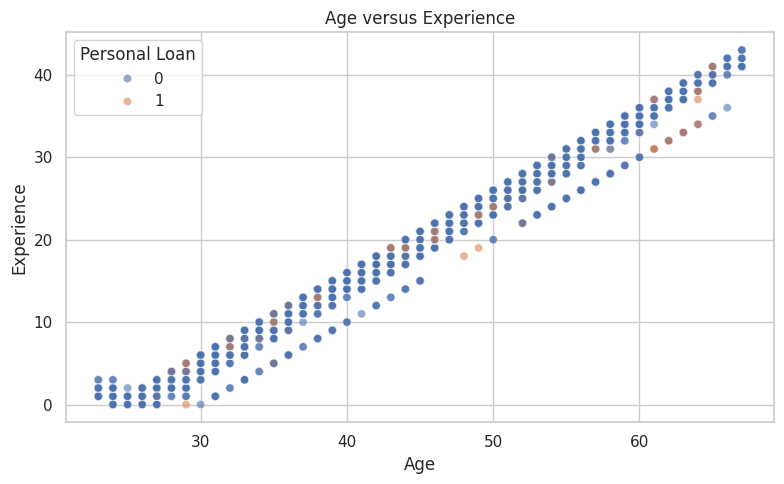

In [88]:
age_experience_correlation = ( df[["Age", "Experience"]].corr().iloc[0, 1])

print( "Correlation between Age and Experience:", round(age_experience_correlation, 4),)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Age",
    y="Experience",
    hue=TARGET,
    alpha=0.6,
)

plt.title("Age versus Experience")
plt.tight_layout()
plt.show()

Do not automatically drop Experience only because it is correlated with Age. Compare cross-validation performance with and without it later. This issue is more important for linear models than for tree-based models.

 **Business-analysis tables**

In [90]:
df["Income Group"] = pd.qcut(df["Income"],q=4,labels=[
        "Low",
        "Lower-Middle",
        "Upper-Middle",
        "High",
    ],
    duplicates="drop",
)

income_group_analysis = (df.groupby( "Income Group", observed=False,)
    .agg(
        Customer_Count=(TARGET, "size"),
        Average_Income=("Income", "mean"),
        Loan_Count=(TARGET, "sum"),
        Loan_Rate=(TARGET, "mean"),
    )
)

income_group_analysis["Loan_Rate"] *= 100
income_group_analysis

,Customer_Count,Average_Income,Loan_Count,Loan_Rate
Income Group,,,,
Low,1312,25.584,0,0.000
Lower-Middle,1238,51.100,2,0.162
Upper-Middle,1204,80.314,34,2.824
High,1246,140.726,444,35.634


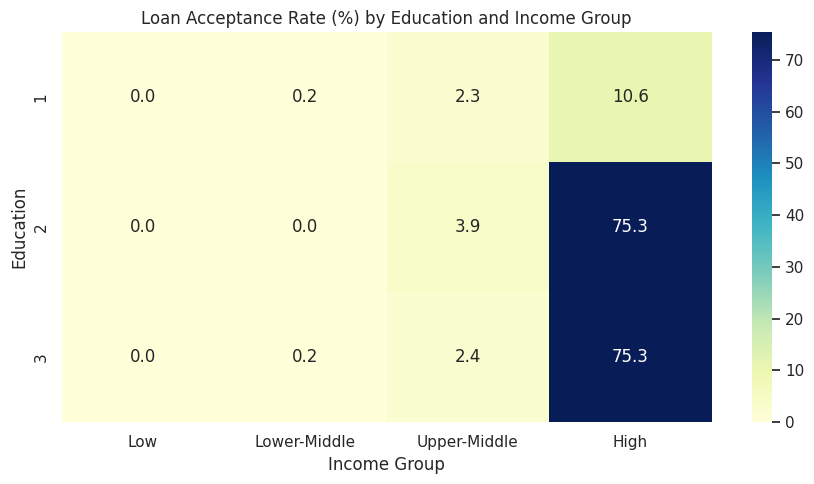

Income Group,Low,Lower-Middle,Upper-Middle,High
Education,,,,
1,0.000,0.233,2.306,10.602
2,0.000,0.000,3.900,75.336
3,0.000,0.234,2.446,75.290


In [92]:
education_income_analysis = (df.groupby(["Education", "Income Group"],observed=False,)
    .agg(Customer_Count=(TARGET, "size"),Loan_Rate=(TARGET, "mean"),)
    .reset_index()
)

education_income_analysis["Loan_Rate"] *= 100

pivot_education_income = (education_income_analysis.pivot(index="Education",columns="Income Group",values="Loan_Rate",))

plt.figure(figsize=(9, 5))

sns.heatmap(pivot_education_income,annot=True,fmt=".1f",cmap="YlGnBu",)

plt.title( "Loan Acceptance Rate (%) by Education and Income Group")
plt.tight_layout()
plt.show()

pivot_education_income

In [94]:
account_analysis = (
    df.groupby(
        ["CD Account", "Securities Account"],
        observed=False,
    )
    .agg(
        Customer_Count=(TARGET, "size"),
        Loan_Count=(TARGET, "sum"),
        Loan_Rate=(TARGET, "mean"),
    )
    .reset_index()
)

account_analysis["Loan_Rate"] *= 100
account_analysis

,CD Account,Securities Account,Customer_Count,Loan_Count,Loan_Rate
0,0,0,4323,331,7.657
1,0,1,375,9,2.400
2,1,0,155,89,57.419
3,1,1,147,51,34.694


In [96]:
df.head()

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard,Income Group
0,25,1,49,91107,4,1.600,1,0,0,1,0,0,0,Lower-Middle
1,45,19,34,90089,3,1.500,1,0,0,1,0,0,0,Low
2,39,15,11,94720,1,1.000,1,0,0,0,0,0,0,Low
3,35,9,100,94112,1,2.700,2,0,0,0,0,0,0,High
4,35,8,45,91330,4,1.000,2,0,0,0,0,0,1,Lower-Middle


In [97]:
df.drop(columns=["Income Group"],inplace=True)

In [98]:
df.to_csv('bank_personal_loan_cleaned.csv',index=False)

In [99]:
pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.7 MB/s eta 0:00:00


In [106]:
df1=pd.read_csv('/content/Bank_Personal_Loan_Modelling.csv')

In [107]:
df1.drop(columns=['ID'],inplace=True)

In [109]:
df1['CCAvg'] = df1['CCAvg'].str.replace('/', '.', regex=False).astype(float)

In [110]:
df1['Experience']=df1['Experience'].apply(abs)

In [111]:
from ydata_profiling import ProfileReport
# Generate profile report
profile = ProfileReport(df1, title="Pandas Profiling Report", explorative=True)

# Save to HTML
profile.to_file("pandas_profiling_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:00<00:00, 70.80it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]